# **World Model - Vision Component (VAE)**

This notebook implements the Perception component of Yann LeCunn's cognitive architecture for visual inputs using a Variational Autoencoder (VAE) approach. We'll train a neural network to learn a compressed latent representation of visual observations from the cart pole environment.

A complete diagnosis of the latent representation learned by the VAE is available on notebook 2.1 "VAE Diagnosis" 

## **Variational Autoencoder (VAE) Architecture**
---

<img src="../media/vae.png" width="900"/>

The VAE consists of an encoder that compresses images into a latent distribution, and a decoder that reconstructs images from samples in the latent space.

### **Loss Function**
The VAE is trained using a composite loss function consisting of:
1. **Reconstruction Loss**: Mean Squared Error (MSE) between original and reconstructed images
2. **Kullback-Leibler Divergence**: Regularization term that ensures the latent space approximates a standard normal distribution
   
$$
\mathcal{L}_{total} = \mathcal{L}_{recon} - \beta \cdot \mathcal{L}_{KL}
$$

$$
\mathcal{L}_{KL} = \sum_{i=1}^{d} D_{KL}\left(q(z_i|x) || \mathcal{N}(0,1) \right) = -\frac{1}{2} \sum_{i=1}^{d} \left(1 + \log\sigma_i^2 - \mu_i^2 - \sigma_i^2\right)
$$
Where $\beta$ is a hyperparameter that controls the importance of the KL term.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
from jepacartpole.models import VAE
from jepacartpole.config import ConfigVAE

import torch
from torchsummary import summary

# Initialize model and display architecture summary
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
vae_config = ConfigVAE()

model = VAE(vae_config).to(DEVICE)

input_size = (3, 400, 600)  
summary(model, input_size)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 200, 300]             784
              ReLU-2         [-1, 16, 200, 300]               0
            Conv2d-3         [-1, 32, 100, 150]           8,224
              ReLU-4         [-1, 32, 100, 150]               0
            Conv2d-5           [-1, 64, 50, 75]          32,832
              ReLU-6           [-1, 64, 50, 75]               0
            Conv2d-7          [-1, 128, 25, 37]         131,200
              ReLU-8          [-1, 128, 25, 37]               0
           Flatten-9               [-1, 118400]               0
           Linear-10                   [-1, 16]       1,894,416
           Linear-11                   [-1, 16]       1,894,416
           Linear-12                [-1, 29600]         503,200
        Unflatten-13           [-1, 32, 25, 37]               0
  ConvTranspose2d-14           [-1, 16,

## **Model Training**
 
The function below handles the VAE training process, including:
 - Moving tensors to the appropriate device (GPU/CPU)
 - Progress tracking with tqdm
 - Loss calculation and backpropagation
 - Model checkpointing


In [2]:
from tqdm import tqdm
import os

def train_vae(model, train_loader, optimizer, num_epochs=10, file_name='vae', folder='checkpoints'):
    model.to(DEVICE)
    model.train()
    
    os.makedirs(folder, exist_ok=True)

    for epoch in range(num_epochs):
        train_loss = 0
        model.train()

        with tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}') as pbar:
            for images, actions, rewards, dones in pbar:
                images = images.to(DEVICE)
                recon, mu, logvar = model(images)
                loss, recon_loss, kl = model.loss(recon, images, mu, logvar)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                pbar.set_postfix(loss=f"{loss.item():.4f} | mse: {recon_loss:.4f} | KL: {kl:.4f}")
                
        avg_epoch_loss = train_loss / len(train_loader)
        print(f'Epoch {epoch + 1}/{num_epochs} | Train Loss: {avg_epoch_loss:.4f}')

    # Save the trained model
    torch.save(model.state_dict(), f'{folder}/{file_name}.pth')

In [3]:
from torch.utils.data import DataLoader
from torch.optim import AdamW

from jepacartpole.datasets import CartPoleVAEDataset 

dataset = CartPoleVAEDataset(h5_path='../data/vae/vae_data.h5')
dataloader = DataLoader(dataset, batch_size=vae_config.batch_size, shuffle=True, num_workers=2)#, pin_memory=True, persistant_workers=True)
optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-6)

In [4]:
%%time
train_vae(model, dataloader, optimizer, num_epochs=vae_config.epochs, file_name = 'vae', folder='../checkpoints')

Epoch 1/4: 100%|██████████| 500/500 [05:43<00:00,  1.45it/s, loss=6445.9429 | mse: 6373.4346 | KL: 36.2542]        


Epoch 1/4 | Train Loss: 38391.0406


Epoch 2/4: 100%|██████████| 500/500 [05:33<00:00,  1.50it/s, loss=7523.3613 | mse: 7453.7075 | KL: 34.8270]    


Epoch 2/4 | Train Loss: 9231.9862


Epoch 3/4: 100%|██████████| 500/500 [05:14<00:00,  1.59it/s, loss=3674.0547 | mse: 3618.5757 | KL: 27.7395]


Epoch 3/4 | Train Loss: 4285.2201


Epoch 4/4: 100%|██████████| 500/500 [05:31<00:00,  1.51it/s, loss=4214.4092 | mse: 4148.7754 | KL: 32.8168]

Epoch 4/4 | Train Loss: 3488.5383
CPU times: user 13min 9s, sys: 3min 9s, total: 16min 19s
Wall time: 22min 4s


### **Load Pre-trained Model**


In [5]:

model.load_state_dict(torch.load('../checkpoints/vae.pth', weights_only=False, map_location=DEVICE ))

<All keys matched successfully>


## **Visualization of Image Reconstruction**---

This section demonstrates the VAE's reconstruction capabilities by comparing original images with their reconstructed versions.
- **Image Comparison**: The `plot_images` function displays original images alongside their reconstructed counterparts
- **Random Sampling**: The `test_vae` function selects random images from the dataset and passes them through the VAE


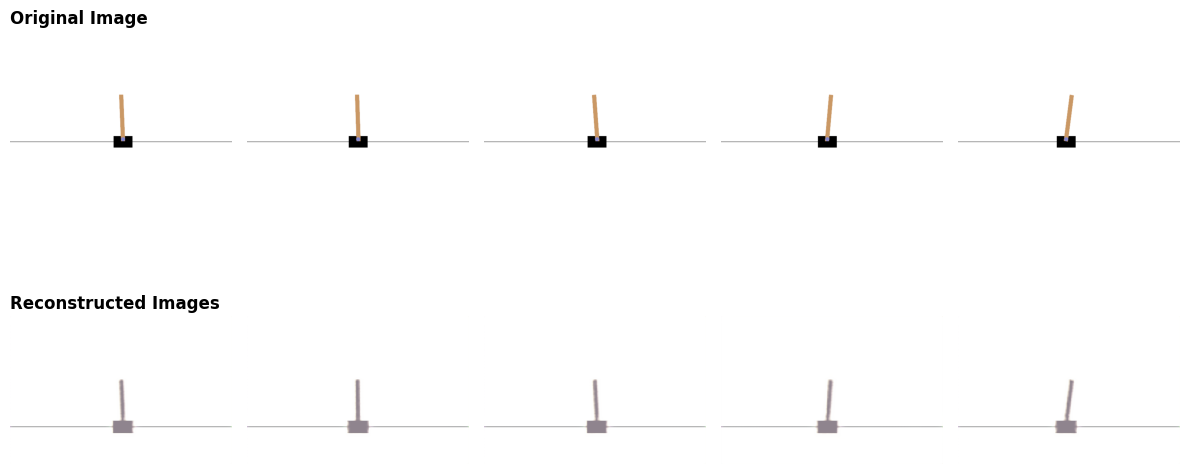

In [6]:
import torch
import matplotlib.pyplot as plt

def plot_images(original, reconstructed, n=4):
    fig, axes = plt.subplots(2, n, figsize=(12, 7))
    
    for i in range(n):
        axes[0, i].imshow(original[i].permute(1, 2, 0).squeeze().cpu().numpy())
        axes[0, i].axis('off')
    axes[0, 0].set_title("Original Image", fontsize=12, fontweight='bold', loc='left')

    for i in range(n):
        axes[1, i].imshow(reconstructed[i].permute(1, 2, 0).squeeze().cpu().numpy())
        axes[1, i].axis('off')
    axes[1, 0].set_title("Reconstructed Images", fontsize=12, fontweight='bold', loc='left')
    plt.tight_layout()
    plt.show()

def test_vae(model, dataloader, n=3):
    model.eval() 
    images = next(iter(dataloader))[0].to(DEVICE)  # Get a batch of images
    
    with torch.no_grad(): 
        reconstructed, _, _ = model(images)

    indices = torch.randperm(images.size(0))[:n]  # Select random images
    plot_images(images[indices], reconstructed[indices], n)

test_vae(model, dataloader, n=5)

Original images - min: 0.000, max: 1.000
Reconstructed - min: 0.002, max: 1.000
Original - mean: 0.989, std: 0.096
Reconstructed - mean: 0.992, std: 0.065
Reconstructed unique values (first 10): [0.9987049  0.9602259  0.9962036  0.9999999  1.         0.99998534
 1.         0.99999714 1.         1.        ]


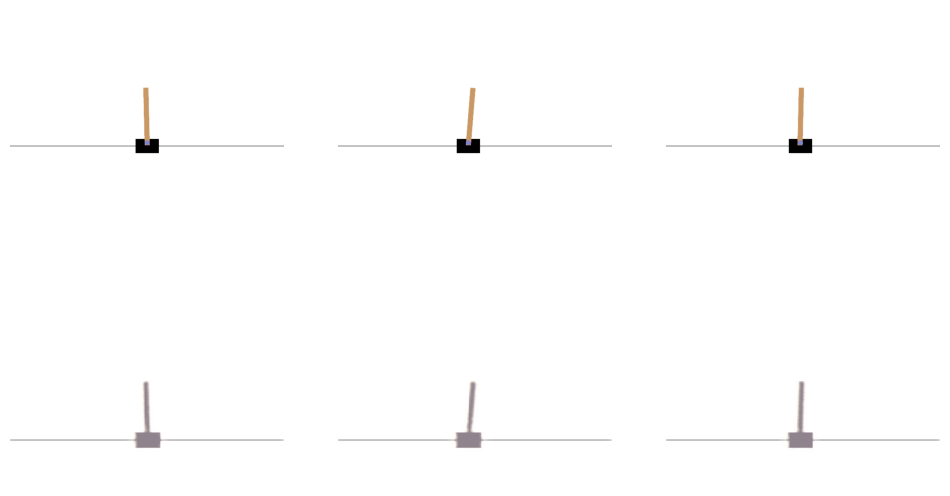

In [8]:
def test_vae(model, dataloader, n=3):
    model.eval() 
    images = next(iter(dataloader))[0].to(DEVICE)
    
    with torch.no_grad(): 
        reconstructed, _, _ = model(images)
    
    # Debug: print value ranges
    print(f"Original images - min: {images.min():.3f}, max: {images.max():.3f}")
    print(f"Reconstructed - min: {reconstructed.min():.3f}, max: {reconstructed.max():.3f}")
    
    indices = torch.randperm(images.size(0))[:n]
    
    
    fig, axes = plt.subplots(2, n, figsize=(12, 7))
    
    for i in range(n):
        orig_img = images[i].permute(1, 2, 0).squeeze().cpu().numpy()
        recon_img = reconstructed[i].permute(1, 2, 0).squeeze().cpu().numpy()
        
        # Print statistics for first image
        if i == 0:
            print(f"Original - mean: {orig_img.mean():.3f}, std: {orig_img.std():.3f}")
            print(f"Reconstructed - mean: {recon_img.mean():.3f}, std: {recon_img.std():.3f}")
            print(f"Reconstructed unique values (first 10): {recon_img.flatten()[:10]}")
        
        axes[0, i].imshow(orig_img)
        axes[0, i].axis('off')
        axes[1, i].imshow(recon_img)
        axes[1, i].axis('off')

test_vae(model, dataloader)

## **Video comparison and future Environment Exploration**

This section allows interaction with the environment while visualizing the VAE's reconstruction capabilities in real-time.
 
- **Controls**: Arrow keys control the cart (←/→: steer)
- **Visualization**: The display shows the original environment observation alongside the VAE's reconstruction
- **Video Recording**: Optional video recording of the interaction session


In [8]:
import os
import gymnasium as gym
from gymnasium.wrappers import AddRenderObservation, TransformObservation
import numpy as np
import torch
import cv2
from PIL import Image

def generate_video(vae_model, scale=1, resolution=(400, 600), video_filename="cart_pole_vae.avi", duration_seconds=6):
    """
    Run the Cart Pole environment with real-time VAE reconstruction visualization for a fixed duration.
    
    Args:
        vae_model: Trained VAE model
        scale: Display scale factor
        resolution: Base resolution for visualization
        save_video: Whether to save a video recording
        video_filename: Output filename for video recording
        duration_seconds: Duration of the video in seconds (default: 6)
    """
    os.makedirs('../videos', exist_ok=True)
    video_filename = os.path.join('../videos', video_filename)
    # resolution = (resolution[0] * 2 * scale, resolution[1] * scale)
    frame_height = resolution[0]  # 400
    frame_width = resolution[1] * 2  # 1200 (600 * 2 for side-by-side)
    
    # Calculate total frames needed (30 FPS * duration in seconds)
    fps = 30
    total_frames = fps * duration_seconds
    frame_count = 0
    
    # Create environment
    env = gym.make('CartPole-v1', render_mode="rgb_array")
    env = AddRenderObservation(env, render_only=True)
    env = TransformObservation(env, lambda obs: np.mean(obs, axis=2, keepdims=True), env.observation_space)
    obs, _ = env.reset()
    
    # Video writer setup
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    video_writer = cv2.VideoWriter(video_filename, fourcc, fps, (frame_width, frame_height), isColor=False)

    running = True
    episode_rewards = []
    current_episode_reward = 0
    
    while running and frame_count < total_frames:
        if not running:
            break
        
        # Use random actions (since interactive is disabled)
        action = np.random.randint(0, 2)
        obs, reward, done, info, _ = env.step(action)
        current_episode_reward += reward

        # Preprocess and reconstruct with VAE
        obs_tensor = torch.Tensor(obs / 255.0).unsqueeze(0).permute(0, 3, 1, 2).to(device)
        with torch.no_grad():
            reconstructed, _, _ = vae_model(obs_tensor)

        # Prepare images for display
        reconstructed = (reconstructed.squeeze(0, 1).cpu().numpy() * 255).astype(np.uint8)
        obs = (obs_tensor.squeeze(0, 1).cpu().numpy() * 255).astype(np.uint8)

        # Combine original and reconstructed images side by side (horizontal concatenation)
        # obs shape: (400, 600), reconstructed shape: (400, 600)
        # full_image shape: (400, 1200)
        full_image = np.concatenate((obs, reconstructed), axis=1)

        # Write frame to video if recording
        video_writer.write(full_image)
        
        frame_count += 1
        
        # Print progress every second
        if frame_count % fps == 0:
            print(f"Progress: {frame_count // fps}/{duration_seconds} seconds recorded")

        # Reset environment if episode is done
        if done:
            print(f"Episode finished with total reward: {current_episode_reward:.2f}")
            episode_rewards.append(current_episode_reward)
            current_episode_reward = 0
            obs, _ = env.reset()

    # Print summary statistics
    if episode_rewards:
        print(f"\nRecording complete! Recorded {len(episode_rewards)} episode(s)")
        print(f"Average episode reward: {np.mean(episode_rewards):.2f}")
        print(f"Min episode reward: {np.min(episode_rewards):.2f}")
        print(f"Max episode reward: {np.max(episode_rewards):.2f}")
    else:
        print(f"\nRecording complete! Recorded {frame_count} frames ({duration_seconds} seconds)")

    # Clean up
    video_writer.release()
    print(f"Video saved to: {video_filename}")

    env.close()

In [9]:
# generate_video(vae_model=model, scale=6)

 ## **Interactive Latent Space Exploration**
 
 This section provides an interactive interface to explore the VAE's latent space and understand its learned representations.
 
 <img src="../media/latent_exploration.png" width="600">
 
 ### Key Features:
 
 - **Latent Vector Manipulation**: Interactive sliders allow adjustment of individual dimensions in the latent space
 - **Real-time Image Generation**: The VAE decoder generates images from the modified latent vectors
 - **Random Sampling**: Generate random points in the latent space to explore its diversity
 - **Dimension Exploration**: A shift slider allows exploration of all latent dimensions (beyond those with dedicated sliders)


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from ipywidgets import FloatSlider, VBox, Button, Output, HBox, IntSlider

LATENT_SIZE = 8
model.eval()

def generate_image(latent_vector):
    """
    Generate an image from a latent vector using the VAE decoder.
    
    Args:
        latent_vector: Vector in the latent space
    
    Returns:
        Generated image as numpy array
    """
    device = next(model.parameters()).device
    with torch.no_grad():
        latent_tensor = torch.tensor(latent_vector, dtype=torch.float32).to(device).unsqueeze(0)
        generated_image = model.decode(latent_tensor).squeeze(0).cpu().numpy()
        return generated_image

# Create sliders for latent space dimensions
num_sliders = 8
sliders = [FloatSlider(value=0.0, min=-3.0, max=3.0, step=0.1, description=f'Latent {i+1}') for i in range(num_sliders)]

output = Output()

def update_image(change):
    """
    Update the displayed image based on the current slider values.
    """
    latent_vector = np.zeros(LATENT_SIZE)
    for i, slider in enumerate(sliders):
        latent_vector[i + shift_slider.value] = slider.value
    generated_image = generate_image(latent_vector)
    
    with output:
        output.clear_output(wait=True)
        plt.figure(figsize=(5, 5))
        plt.imshow(generated_image.transpose(1, 2, 0), cmap="gray")
        plt.axis('off')
        plt.title('Generated Image')
        plt.show()

def update_slider_labels(shift_value):
    """
    Update slider labels based on the shift value.
    """
    for i, slider in enumerate(sliders):
        slider.description = f'Latent {i + 1 + shift_value}'

# Link sliders to update function
for slider in sliders:
    slider.observe(update_image, 'value')

def generate_random_latent(button):
    """
    Generate a random latent vector and update sliders.
    """
    latent_vector = np.random.uniform(-3.0, 3.0, size=LATENT_SIZE)
    for i, slider in enumerate(sliders):
        slider.value = latent_vector[i + shift_slider.value]
    update_image(None)

# Create buttons
random_button = Button(description='Random Vector', 
                      tooltip='Generate random latent vector values',
                      style={'button_color': '#3498db'})
random_button.on_click(generate_random_latent)

reset_button = Button(description='Reset Sliders', 
                     tooltip='Reset all sliders to zero',
                     style={'button_color': '#e74c3c'})
def reset_sliders(button):
    """
    Reset all sliders to zero.
    """
    for slider in sliders:
        slider.value = 0.0
    update_image(None)
reset_button.on_click(reset_sliders)

# Shift slider to adjust which latent dimensions the other sliders modify
shift_slider = IntSlider(value=0, min=0, max=LATENT_SIZE - num_sliders, step=1, 
                        description='SHIFT',
                        tooltip='Shift which latent dimensions are controlled by sliders')
shift_slider.observe(lambda change: update_slider_labels(shift_slider.value), 'value')
shift_slider.observe(update_image, 'value')

# Create a vertical box for sliders, shift slider, and buttons with padding
slider_box = VBox(sliders + [shift_slider, random_button, reset_button], layout={'margin': '30px 0 0 0'})

# Create a horizontal box to hold the image output and sliders
layout = HBox([output, slider_box])

# Display the layout
display(layout)

# Generate an initial image and set initial slider labels
update_slider_labels(shift_slider.value)
update_image(None)

In [10]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import animation
import matplotlib
matplotlib.use('Agg')  # Use non-interactive backend
from tqdm import tqdm

def create_enhanced_animation(
    model,
    output_path='enhanced_animation.mp4',
    fps=30,
    resolution=(640, 480),
    latent_size=8,
    amplitude=5.0  # Increased amplitude for more significant variations
):
    """
    Create an enhanced animation that produces more significant variations
    with an improved visualization of dimension changes.
    """
    model.eval()
    device = next(model.parameters()).device
    
    # Create figure with two subplots - one for the image and one for visualization
    fig = plt.figure(figsize=(resolution[0]/100, resolution[1]/100), dpi=100)
    img_ax = plt.subplot2grid((4, 4), (0, 0), colspan=3, rowspan=3)  # Image takes most space
    viz_ax = plt.subplot2grid((4, 4), (0, 3), rowspan=3)  # Dimension visualization on right
    info_ax = plt.subplot2grid((4, 4), (3, 0), colspan=4)  # Info panel at bottom
    info_ax.axis('off')
    
    # Pre-compute which dimensions have the most impact on the output
    # We'll do this by testing each dimension individually
    print("Analyzing dimensions for impact...")
    dimension_impact = []
    
    base_latent = np.zeros(latent_size)
    base_image = None
    
    with torch.no_grad():
        # Generate base image with zero latent
        base_tensor = torch.tensor(base_latent, dtype=torch.float32).to(device).unsqueeze(0)
        base_image = model.decode(base_tensor).squeeze(0).cpu().numpy()
        
        # Test each dimension
        for dim in range(latent_size):
            test_latent = base_latent.copy()
            test_latent[dim] = amplitude  # Use maximum amplitude
            
            test_tensor = torch.tensor(test_latent, dtype=torch.float32).to(device).unsqueeze(0)
            test_image = model.decode(test_tensor).squeeze(0).cpu().numpy()
            
            # Calculate mean squared difference as impact measure
            impact = np.mean((test_image - base_image) ** 2)
            dimension_impact.append((dim, impact))
    
    # Sort dimensions by impact
    dimension_impact.sort(key=lambda x: x[1], reverse=True)
    top_dimensions = [dim for dim, _ in dimension_impact[:10]]  # Top 10 impactful dimensions
    
    print(f"Most impactful dimensions: {top_dimensions}")
    
    # Animation plan using most impactful dimensions:
    frames_per_segment = 60
    
    # Different animation segments
    segments = [
        # Sine waves on top dimensions
        {"type": "sine_wave", "dimensions": top_dimensions[:3], "frames": frames_per_segment},
        
        # Morphing between random latent vectors focused on top dimensions
        {"type": "random_morph", "dimensions": top_dimensions, "frames": frames_per_segment},
        
        # Circular pattern in pairs of top dimensions
        {"type": "circular", "dimensions": [top_dimensions[0], top_dimensions[1]], "frames": frames_per_segment},
        
        # Wave pattern across all top dimensions
        {"type": "wave", "dimensions": top_dimensions, "frames": frames_per_segment},
        
        # Counterpoise pattern (some dimensions increase while others decrease)
        {"type": "counterpoise", "dimensions": top_dimensions[:6], "frames": frames_per_segment}
    ]
    
    # Calculate total frames
    total_frames = sum(segment["frames"] for segment in segments)
    
    # Generate random vectors focused on top dimensions
    def generate_focused_random_vector():
        v = np.zeros(latent_size)
        for dim in top_dimensions:
            v[dim] = np.random.normal(0, amplitude/2)
        return v
    
    # Generate a few random vectors for morphing
    random_vectors = [generate_focused_random_vector() for _ in range(4)]
    
    # Add the first vector at the end to create a loop
    random_vectors.append(random_vectors[0].copy())
    
    # Function to update the dimension visualization
    def update_dimension_viz(latent_vector, title=None):
        viz_ax.clear()
        
        # Display top dimensions as vertical bars
        positions = np.arange(len(top_dimensions))
        values = [latent_vector[dim] for dim in top_dimensions]
        
        # Color bars based on value (blue for negative, red for positive)
        colors = []
        for val in values:
            if val > 0:
                # Red intensity based on positive value
                intensity = min(1.0, abs(val) / amplitude)
                colors.append((1.0, 0.4 * (1-intensity), 0.4 * (1-intensity)))
            else:
                # Blue intensity based on negative value
                intensity = min(1.0, abs(val) / amplitude)
                colors.append((0.4 * (1-intensity), 0.4 * (1-intensity), 1.0))
                
        viz_ax.barh(positions, values, color=colors)
        viz_ax.set_yticks(positions)
        viz_ax.set_yticklabels([f"D{dim}" for dim in top_dimensions])
        viz_ax.set_xlim(-amplitude, amplitude)
        viz_ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
        viz_ax.set_title("Top Dimensions" if not title else title)
    
    # Track which segment we're in
    current_frame = 0
    segment_start_frames = [0]
    for segment in segments:
        segment_start_frames.append(segment_start_frames[-1] + segment["frames"])
    total_frames = segment_start_frames[-1]  # Use the last element as total frames

    def generate_frame(frame_num):
        nonlocal current_frame
        current_frame = frame_num

        # Determine which segment we're in
        segment_idx = 0
        while segment_idx < len(segments) and frame_num >= segment_start_frames[segment_idx + 1]:
            segment_idx += 1

        segment = segments[segment_idx]
        segment_frame = frame_num - segment_start_frames[segment_idx]
        segment_progress = segment_frame / segment["frames"]
        
        # Initialize latent vector
        latent_vector = np.zeros(latent_size)
        segment_title = None
        
        if segment["type"] == "sine_wave":
            # Simple sine wave on top dimensions with different phases
            for i, dim in enumerate(segment["dimensions"]):
                phase = i * (2 * np.pi / len(segment["dimensions"]))
                latent_vector[dim] = amplitude * np.sin(segment_progress * 2 * np.pi + phase)
            segment_title = "Sine Wave Pattern"
            
        elif segment["type"] == "random_morph":
            # Morphing between random vectors
            morph_idx = int(segment_progress * (len(random_vectors) - 1))
            morph_progress = segment_progress * (len(random_vectors) - 1) - morph_idx
            
            start_vector = random_vectors[morph_idx]
            end_vector = random_vectors[morph_idx + 1]
            
            latent_vector = start_vector + morph_progress * (end_vector - start_vector)
            segment_title = f"Random Vector Morphing {morph_idx+1}/{len(random_vectors)-1}"
            
        elif segment["type"] == "circular":
            # Circular pattern in 2D space of top dimensions
            dim1, dim2 = segment["dimensions"][:2]
            latent_vector[dim1] = amplitude * np.cos(segment_progress * 2 * np.pi)
            latent_vector[dim2] = amplitude * np.sin(segment_progress * 2 * np.pi)
            segment_title = f"Circular Pattern D{dim1}-D{dim2}"
            
        elif segment["type"] == "wave":
            # Wave effect across dimensions
            for i, dim in enumerate(segment["dimensions"]):
                phase = i * (4 * np.pi / len(segment["dimensions"]))
                latent_vector[dim] = amplitude * np.sin(segment_progress * 6 * np.pi + phase)
            segment_title = "Wave Pattern"
            
        elif segment["type"] == "counterpoise":
            # Some dimensions increase while others decrease
            half = len(segment["dimensions"]) // 2
            for i, dim in enumerate(segment["dimensions"][:half]):
                latent_vector[dim] = amplitude * segment_progress
            for i, dim in enumerate(segment["dimensions"][half:]):
                latent_vector[dim] = amplitude * (1 - segment_progress)
            segment_title = "Counterpoise Pattern"
        
        # Generate image from latent vector
        with torch.no_grad():
            latent_tensor = torch.tensor(latent_vector, dtype=torch.float32).to(device).unsqueeze(0)
            generated_image = model.decode(latent_tensor).squeeze(0).cpu().numpy()
        
        # Display the image
        img_ax.clear()
        img_ax.imshow(generated_image.transpose(1, 2, 0), cmap="gray")
        img_ax.axis('off')
        
        # Update dimension visualization
        update_dimension_viz(latent_vector, segment_title)
        
        # Update info panel
        info_ax.clear()
        info_ax.axis('off')
        active_dims = [dim for dim in segment["dimensions"] if abs(latent_vector[dim]) > 0.1]
        
        # Create textual description of what's happening
        description = f"{segment_title} - Frame {segment_frame+1}/{segment['frames']}\n"
        if active_dims:
            description += f"Active dimensions: " + ", ".join([f"D{dim}:{latent_vector[dim]:.2f}" for dim in active_dims[:5]])
            if len(active_dims) > 5:
                description += f" and {len(active_dims)-5} more..."
        
        info_ax.text(0.5, 0.5, description, ha='center', va='center', fontsize=9)
        
        # Very important to ensure figure is properly formatted
        fig.tight_layout()
        return [img_ax, viz_ax, info_ax]
    
    # Generate animation
    print(f"Generating enhanced animation with {total_frames} frames...")
    anim = animation.FuncAnimation(fig, generate_frame, frames=total_frames, blit=False)
    
    # Save the animation
    print(f"Saving animation to {output_path}...")
    writer = animation.FFMpegWriter(fps=fps, metadata=dict(artist='VAE Latent Space Explorer'), bitrate=5000)
    anim.save(output_path, writer=writer)
    
    plt.close()
    print(f"Enhanced animation saved to {output_path}")



# Create enhanced animation
create_enhanced_animation(
    model=model,
    output_path='../videos/modern_latent_animation.mp4',
    fps=30,
    resolution=(800, 600),  # Larger resolution for better visibility
    amplitude=5.0  # Increased amplitude for more significant variations
)



Analyzing dimensions for impact...
Most impactful dimensions: [2, 3, 7, 1, 5, 6, 0, 4]
Generating enhanced animation with 300 frames...
Saving animation to ../videos/modern_latent_animation.mp4...
Enhanced animation saved to ../videos/modern_latent_animation.mp4
